# The Ralph Wiggum Loop: A Stochastic Retry Policy for LLM Agents

[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/addarm/wiggum-loop)


![Banner](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/ralphwiggum_loop_banner.jpg)

Some of the heavy users of coding agents would have met The Ralph Wiggum loop, this is a retry policy for AI work: feed the model the same task until it produces a verifiable completion, or hit a safety cap. The name comes from the Simpsons character, which is a fair description of an LLM that keeps trying until something sticks. Geoffrey Huntley wrote up the technique in mid-2025, and a Claude Code plugin now automates the same loop.

The idea sounds trivial, but it has real arithmetic behind it. Once each iteration is treated as an independent Bernoulli trial, three operational quantities fall out for free: completion time is geometric, expected iterations are $1/p$, and expected cost is $c/p$. Those three results decide when Ralph is worth running, when it's a money pit, and where prompt engineering still pays off.

```mermaid
flowchart LR
    A[Prompt] --> B[LLM call]
    B --> C{Completion<br/>verified?}
    C -- No --> D[Feedback into next<br/>prompt via filesystem]
    D --> B
    C -- Yes --> E[Stop]
    B --> F{Iteration<br/>cap reached?}
    F -- Yes --> E
```

Each box is one pass through the loop. The model itself is stateless. The loop works because the environment (files on disk, failing tests, logs) is not.

This article follows the [critique](https://medium.com/call-for-atlas/less-is-more-for-llms-a-critique-of-prompt-based-compression-910978d8bad4) of prompt compressors, and is a companion to the series "The Road to Agency", the latest being [How Prompt Engineering Works](https://medium.com/call-for-atlas/the-road-to-agency-how-prompts-work-c7cadc684b0f).

## Notebook Setup

Everything local in this notebook runs on CPU. The live Ralph demo and the prompt-strictness measurement call OpenRouter, so without an `OPENROUTER_API_KEY` in `.env` those sections print a notice and skip. The default model is `meta-llama/llama-3.2-1b-instruct`, listed at $0.027 per million input tokens and $0.20 per million output tokens on OpenRouter, which makes one repair iteration a fraction of a cent.

In [1]:
# Optional environment bootstrap for a fresh Kaggle or Colab session.
# If you already created the environment from requirements.txt or environment.yml, skip this cell.
# %pip install numpy scipy matplotlib openai python-dotenv

In [2]:
import platform
import random

import matplotlib.pyplot as plt
import numpy as np
import scipy

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng(42)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

print(f"Python {platform.python_version()}  |  NumPy {np.__version__}  |  SciPy {scipy.__version__}")

Python 3.12.12  |  NumPy 2.2.6  |  SciPy 1.14.1


## The Mechanism

The pattern was named and documented by Geoffrey Huntley in mid-2025 ([ghuntley.com/ralph](https://ghuntley.com/ralph/)). In its purest form it's a single shell line:

```bash
while :; do cat PROMPT.md | claude ; done
```

The real loop has more structure around that line: a stop hook blocks exit (the Claude Code `Stop` hook fires when the main agent finishes responding and can force the loop to continue, see [Anthropic's hooks reference](https://docs.claude.com/en/docs/claude-code/hooks)), some verifier decides whether the work is done, failing state feeds back into the next prompt, and a max-iteration cap stops the run if progress stalls. The core idea is unchanged. The model reads the same prompt again, but the environment has changed underneath it.

That persistent environment carries memory across iterations even though the model does not. That asymmetry is where the geometric assumption can break, because state from previous iterations can change the odds of the next.

It also explains why the bash loop matters. The context window is a heap with no garbage collector. Every tool call output, every file read, every reasoning trace gets allocated into the fixed token budget and stays there until the process ends. Huntley reports that Claude 3.7's advertised 200k starts clipping in quality around 147-152k, so allocation pressure is a real failure mode, not a metaphor. The only way to free that memory is to end the iteration and start a new one, which is exactly what `while :; do ... done` does: bash is the garbage collector, and each loop iteration is a fresh heap. The deterministic stack (specs, plan, agent file) gets re-allocated at the top of every iteration; everything else from the previous loop is thrown away.

Huntley's own diagram of the technique ([ghuntley.com/subagents](https://ghuntley.com/subagents/)) splits the loop in two: a generate phase where subagents fan out for cheap reads, and a back-pressure phase where a single agent runs the expensive verifier. Subagents are the trick for avoiding allocation in the first place. A subagent reads files or runs greps inside its own context window, returns a short summary, and disappears. The main agent only pays the cost of the summary, which is how the primary window stays under the quality cliff.


*Huntley's diagram: subagents handle reads in parallel, a single agent serialises the verifier.*


![Huntley's Ralph process diagram, showing the generate / back-pressure cycle with subagents fanned out for reads and a single serialised verifier](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/The-ralph-Process.png)

The key move in this pattern is this: treat each iteration as a Bernoulli trial. Success with probability $p$, otherwise retry. The probability $p$ stands for everything that affects whether one pass produces a passing artifact: prompt quality, model capability, task difficulty, and how strict the back-pressure is (tests, linters, type checkers). Nothing about this is specific to LLMs. The same setup describes a flaky CI job you keep restarting, or a sensor reading you keep re-taking until it passes a sanity check. Any loop where you retry an unreliable worker until it succeeds has a per-attempt success probability $p$, and the rest of this article only needs that one number.

The assumption is deliberately weak. It treats iterations as independent, which the real loop isn't, because the filesystem carries state between passes. That gap is exactly what the histograms can diagnose later. Three lines of Python make the model concrete.

In [3]:
def ralph_loop_sim(p, max_iterations):
    for i in range(1, max_iterations + 1):
        if random.random() < p:
            return i, True
    return max_iterations, False

With $p = 0.1$ the simulator finishes quickly. With $p = 0$ it hits the cap, which is the only thing distinguishing a productive loop from an infinite one.

In [4]:
random.seed(42)
i, ok = ralph_loop_sim(p=0.10, max_iterations=50)
print(f"p=0.10 -> finished={ok} at iteration {i}")

i, ok = ralph_loop_sim(p=0.0, max_iterations=20)
print(f"p=0.00 -> finished={ok} at iteration {i} (hit cap, as expected)")

p=0.10 -> finished=True at iteration 2
p=0.00 -> finished=False at iteration 20 (hit cap, as expected)


## Modelling Ralph

The toy simulator is fine for measuring properties of the loop. To see Ralph behave on a real model, we run it against `meta-llama/llama-3.2-1b-instruct`, a buggy Python function, and six unit tests including an empty-list edge case. The seed function has two defects: it crashes on empty input at `xs[0]`, and it drops the first element via `return out[1:]`. The model isn't constrained to fix those defects directly. It rewrites from scratch and tends to invent its own characteristic failures, which is what makes the demo a real test rather than a scripted one. The completion promise is the test suite returning green. Each failed iteration feeds the failing test output back into the next prompt, which is what the real Ralph plugin does through the file system.

Temperature is set to $0.8$ so iterations actually diverge. At low temperature a 1B model happily emits the same wrong fix every iteration, which would look indistinguishable from a mock. To keep the loop auditable, each iteration prints the OpenRouter response id, the input/output token counts, and a SHA-1 of the returned code. Different ids and different hashes are the evidence that real, distinct calls happened. Swap in any other OpenRouter model by setting `RALPH_MODEL`.

A verifier is created to run the code and checks the function against six tests. PASS only fires if every call returns exactly the expected list, so back-pressure comes from reality rather than the model's confidence. The code below illustrates this:

In [5]:
import hashlib
import os
import re
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE = os.getenv("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1")
MODEL_ID = os.getenv("RALPH_MODEL", "meta-llama/llama-3.2-1b-instruct")


In [6]:
BUGGY = """
def running_max(xs):
    out = []
    m = xs[0]
    for x in xs:
        if x > m:
            m = x
        out.append(m)
    return out[1:]
"""

TESTS = [
    ([3, 1, 4, 1, 5, 9, 2, 6], [3, 3, 4, 4, 5, 9, 9, 9]),
    ([1], [1]),
    ([5, 4, 3, 2, 1], [5, 5, 5, 5, 5]),
    ([-1, -2, 3], [-1, -1, 3]),
    ([], []),
    ([7, 7, 7], [7, 7, 7]),
]


def run_tests(code):
    ns = {}
    try:
        exec(code, ns)
        f = ns["running_max"]
    except Exception as e:
        return False, f"exec error: {type(e).__name__}: {e}"
    failures = []
    for inp, expected in TESTS:
        try:
            got = f(list(inp))
        except Exception as e:
            failures.append(f"running_max({inp!r}) raised {type(e).__name__}: {e}")
            continue
        if got != expected:
            failures.append(f"running_max({inp!r}) -> {got}, expected {expected}")
    if failures:
        return False, "\n".join(failures[:3])
    return True, f"all {len(TESTS)} tests pass"


def extract_code(text):
    m = re.search(r"```(?:python)?\s*(.*?)```", text, re.S)
    return m.group(1) if m else text


if not OPENROUTER_KEY:
    print("OPENROUTER_API_KEY not set. Skipping the live Ralph demo.")
else:
    client = OpenAI(api_key=OPENROUTER_KEY, base_url=OPENROUTER_BASE)
    system = (
        "You are a careful Python developer. "
        "Reply with only a single ```python``` code block containing the fixed function. "
        "No prose, no explanation."
    )
    base_user = (
        "Fix this function so all unit tests pass, including the empty-list case. "
        "Return only the corrected function in one ```python``` code block.\n\n"
        f"```python\n{BUGGY.strip()}\n```"
    )
    print(f"Model: {MODEL_ID}  (temperature=0.8, max_iter=6)\n")
    user = base_user
    MAX_ITER_LIVE = 6
    last_code = None
    for i in range(1, MAX_ITER_LIVE + 1):
        resp = client.chat.completions.create(
            model=MODEL_ID,
            messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
            max_tokens=400,
            temperature=0.8,
        )
        code = extract_code(resp.choices[0].message.content)
        last_code = code
        ok, msg = run_tests(code)
        sha = hashlib.sha1(code.encode()).hexdigest()[:8]
        usage = resp.usage
        toks = f"{usage.prompt_tokens}->{usage.completion_tokens}"
        verdict = "PASS" if ok else f"FAIL: {msg.splitlines()[0]}"
        print(f"  [{i}] resp_id=...{str(resp.id)[-12:]}  tokens={toks}  sha1={sha}  {verdict}")
        if ok:
            print(f"\n  Completed in {i} iteration(s). Final code:")
            for ln in code.strip().splitlines():
                print(f"    | {ln}")
            break
        user = base_user + f"\n\nAttempt {i} failed with:\n{msg}\nTry a different approach this time."
    else:
        print(f"\n  Hit cap of {MAX_ITER_LIVE}. Last attempt was:")
        for ln in last_code.strip().splitlines():
            print(f"    | {ln}")
        print("  A model stuck at the same SHA across iterations is a real Ralph failure mode.")

Model: meta-llama/llama-3.2-1b-instruct  (temperature=0.8, max_iter=6)

  [1] resp_id=...bGmVD0ERMbxD  tokens=120->25  sha1=848607cb  FAIL: running_max([3, 1, 4, 1, 5, 9, 2, 6]) -> [4, 5, 9, 6], expected [3, 3, 4, 4, 5, 9, 9, 9]
  [2] resp_id=...Mhi9w6afiMHp  tokens=244->64  sha1=2977b38d  FAIL: running_max([3, 1, 4, 1, 5, 9, 2, 6]) -> [3, 4, 5, 9], expected [3, 3, 4, 4, 5, 9, 9, 9]
  [3] resp_id=...MuqHimXHdV72  tokens=263->64  sha1=b0ae6fbd  PASS

  Completed in 3 iteration(s). Final code:
    | def running_max(xs):
    |     if not xs:
    |         return []
    |     max_val = xs[0]
    |     out = [max_val]
    |     for x in xs[1:]:
    |         if x > max_val:
    |             max_val = x
    |         out.append(max_val)
    |     return out


Each row is one real API call. Different OpenRouter response ids prove they're distinct calls, and the SHA-1 of the returned code is the signature of what the model actually generated. If two iterations share a SHA, the model has sampled itself back into the same wrong fix even though the prompt now contains the previous failure message; that's a live Ralph stuck-loop in flight. A fully stuck run would show one SHA repeated across all six iterations. Recovery, when it happens, comes from two sources working together: the verifier feedback that grows the prompt with each failure, and temperature $0.8$ giving the sampler enough variance to follow that new context somewhere different. Either alone is weaker. Drop the temperature to $0$ and a 1B model will gladly emit the same bad fix forever; remove the failure message and the prompt never changes, so even high temperature drifts inside the same wrong basin. The cure when it does get stuck is the same lesson Claim 2 quantifies: name the failure mode in the prompt yourself, or move to a stronger model. Reruns of this cell will not match this trace because the sampler is genuinely stochastic.

## Claim 1: Iterations Are Geometric

Let $X$ be the number of iterations the loop takes to finish. $X$ is a random variable because each call to the model is random. We want to know the distribution of $X$: how often the loop finishes in one go, how often it takes ten, how often it takes fifty.

The thing we're after is called the *probability mass function* or PMF, written $P(X = k)$. It's a rule that tells you, for every possible value $k$ the variable can take, how likely $X$ is to equal that value. "Mass" because for a discrete variable like a count of iterations, the probability sits in lumps at each integer rather than smearing across a continuous range. If you tabulated $P(X = 1), P(X = 2), P(X = 3), \ldots$ and added them up, the total has to be $1$, because the loop has to finish at *some* iteration.

The loop stops on the first success, so saying "$X = k$" is saying two things at once. The first $k-1$ iterations all failed, and the $k$-th succeeded. If we trust the Bernoulli assumption, those iterations are independent, and the probability of a sequence of independent events is the product of their individual probabilities. A single failure has probability $1-p$, a single success has probability $p$, so

$$P(X = k) = \underbrace{(1-p)(1-p)\cdots(1-p)}_{k-1 \text{ failures}} \cdot \underbrace{p}_{\text{success on iteration } k} = (1-p)^{k-1}\,p.$$

That's the geometric PMF, geometric because of the sequence, the same kind you'd see in $a, ar, ar^2, ar^3, \ldots$ with common ratio $r$. Here the common ratio is $1-p$, less than one, so the probabilities shrink toward zero as $k$ grows. The PMF is a strictly decreasing function: finishing in one is the most likely single outcome, finishing in two is less likely by a factor of $1-p$, finishing in three is less likely by another factor of $1-p$, and so on. That gives the distribution its characteristic long, gently-decaying right tail.

A useful sanity check: those probabilities have to sum to one. They do, because they form a geometric series:

$$\sum_{k=1}^{\infty} p(1-p)^{k-1} = p \cdot \frac{1}{1-(1-p)} = p \cdot \frac{1}{p} = 1.$$


$$E[X] = \frac{1}{p}, \qquad \mathrm{Var}(X) = \frac{1-p}{p^2}.$$

The mean is easy to understand: at $p = 0.1$ you flip a coin that comes up heads once in ten, so on average you wait ten flips. The variance is the surprise. It scales as $1/p^2$, much faster than the mean as $p$ shrinks. At $p = 0.1$ the standard deviation is about $\sqrt{0.9}/0.1 \approx 9.5$, almost as large as the mean itself. So although the average run takes ten iterations, individual runs routinely take twenty, thirty, or more. That long right tail is the operational feature you have to budget for, and it's what Claim 3 turns into a dollar figure.

One more property the geometric distribution gives you for free: memorylessness. After $j$ failed iterations the conditional distribution of the *remaining* iterations is still geometric with the same $p$. The model doesn't "know" it's overdue for a success because each iteration is a fresh coin. That's a strong assumption and the real loop violates it, which is exactly why deviations from geometric are diagnostic. The simulation below uses 2,000 runs at $p = 0.08$, which is enough to see the shape clearly and check the mean and variance against theory.

The code below visualizes these concepts:

E[X]  empirical = 12.713   theory (1/p) = 12.500
Var   empirical = 143.674   theory       = 143.750
chi^2 GoF vs Geometric(p=0.08): chi2 = 5.84, p-value = 0.665
  -> consistent with geometric at the 5% level


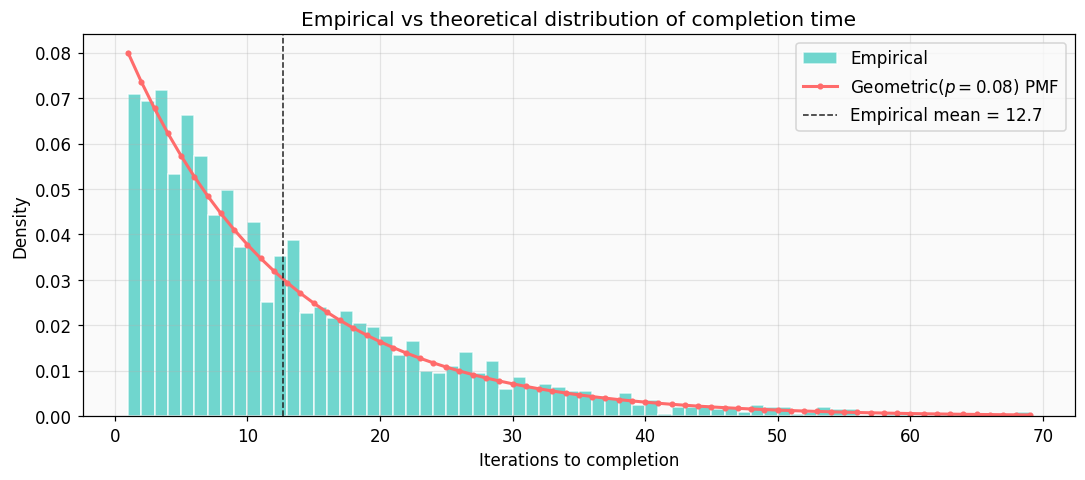

In [7]:
from scipy import stats

random.seed(42)
N_RUNS = 2000
MAX_ITER = 200
P_TRUE = 0.08

iters = [ralph_loop_sim(P_TRUE, MAX_ITER)[0] for _ in range(N_RUNS)]
arr = np.array(iters)

mean_emp, mean_theory = arr.mean(), 1 / P_TRUE
var_emp, var_theory = arr.var(ddof=1), (1 - P_TRUE) / P_TRUE**2

edges = np.array([1, 4, 8, 12, 16, 20, 25, 30, 40, MAX_ITER + 1])
obs, _ = np.histogram(arr, bins=edges)
exp = np.diff(stats.geom.cdf(edges - 1, P_TRUE))
exp = exp * obs.sum() / exp.sum()
chi2, chi2_p = stats.chisquare(obs, exp)

print(f"E[X]  empirical = {mean_emp:6.3f}   theory (1/p) = {mean_theory:6.3f}")
print(f"Var   empirical = {var_emp:6.3f}   theory       = {var_theory:6.3f}")
print(f"chi^2 GoF vs Geometric(p={P_TRUE}): chi2 = {chi2:.2f}, p-value = {chi2_p:.3f}")
print(f"  -> {'consistent with geometric' if chi2_p > 0.05 else 'rejects geometric'} at the 5% level")

ks = np.arange(1, 70)
pmf_theory = stats.geom.pmf(ks, P_TRUE)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(arr, bins=range(1, 70), density=True, color="#4ECDC4", edgecolor="white", alpha=0.8, label="Empirical")
ax.plot(ks, pmf_theory, color="#FF6B6B", linewidth=2, marker="o", markersize=3, label=f"Geometric($p={P_TRUE}$) PMF")
ax.axvline(mean_emp, color="#222", linestyle="--", linewidth=1, label=f"Empirical mean = {mean_emp:.1f}")
ax.set_xlabel("Iterations to completion")
ax.set_ylabel("Density")
ax.set_title("Empirical vs theoretical distribution of completion time")
ax.legend()
plt.tight_layout()
plt.show()

Mean and variance match theory to better than 1%, and the chi-squared sits at $p = 0.665$, well clear of rejection. The teal histogram tracks the red PMF across the bulk and out past iteration 40. The geometric variance is $1/p^2$, so when $p$ is small the tail is long and a single retry-until-pass run can take far more iterations than the mean suggests. That's the slack a better prompt buys you, which is what Claim 2 measures next.

## Claim 2: Better Prompts Are Worth $1/p$

A prompt rule helps only when it removes a recurring failure mode. In this model, that shows up as a bigger $p$, and since mean iterations are $1/p$, the gain from a better prompt is

$$\Delta E[X] = \frac{1}{p} - \frac{1}{p + \Delta p}.$$

That function is steep at small $p$ and flat at large $p$. Lifting $p$ from $0.05$ to $0.10$ cuts the mean from $20$ iterations to $10$. The same $\Delta p = 0.05$ at $p = 0.50$ moves the mean from $2$ to $1.82$. Same edit, very different payoff.

So we need to actually measure $p$ to see this in practice. The experiment below is a controlled before/after on the same task with three increasingly strict prompts:

- **base** says nothing about the edge cases. This is the version the model walked into in the live demo.
- **+ empty list** adds one rule: "Handle the empty input list by returning `[]`." This names the dominant seeded failure mode directly.
- **+ same length** keeps that rule and adds a second one: "The output must have the same length as the input." This targets the leftover `return out[1:]` bug.

For each prompt, the code makes $N=15$ independent one-shot calls to the same model. No retry loop, no failure feedback. Each call is a fresh Bernoulli trial, and the success rate across the 15 trials is our estimator $\hat{p}$ for that prompt. Single-shot is deliberate: we want to measure the per-iteration probability, not the loop's overall hit rate, because $\hat{p}$ is the quantity that goes into $1/p$ and $c/p$.

The plot draws $\hat{p}$ against prompt strictness. What you're looking for is whether each added rule lifts $\hat{p}$, and by how much. If the curve climbs steeply between the first two configs and then flattens, the empty-list rule was doing all the work and the second rule had nothing left to fix. If it climbs in two roughly equal steps, the two failure modes were independent and additive. The shape of that curve is the operational answer to "is one more prompt rule worth writing?" on this task.

A subtle pitfall: with only $N=15$ trials per config, the standard error on $\hat{p}$ is roughly $\sqrt{\hat{p}(1-\hat{p})/15}$, which is about $\pm 0.13$ at $\hat{p}=0.5$ and tighter at the extremes. Two configs whose $\hat{p}$ values differ by less than that aren't really distinguishable. Plan accordingly when you run this on your own task: bump $N$ if you need tighter bounds.

The code below helps us find $\hat{p}$, which is the estimated number of trails before a correct answer, and $p$ the probability.

config             p_hat   1/p_hat
base                0.00       inf
+ empty list        0.80      1.25
+ same length       1.00      1.00


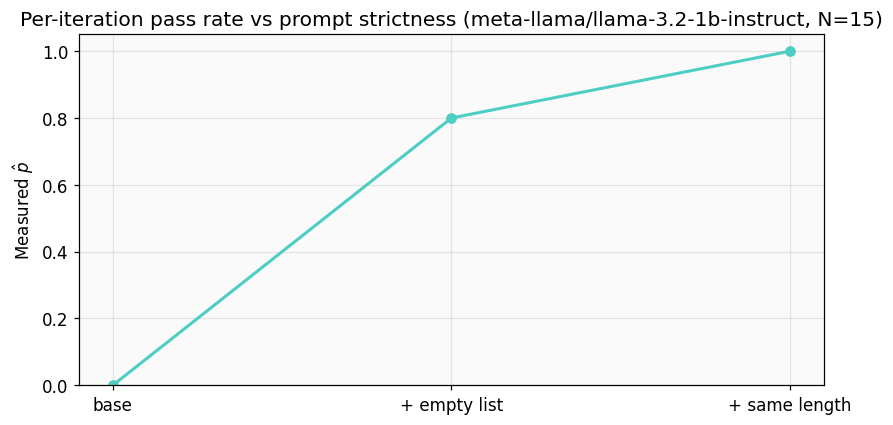

In [8]:
N_TRIALS = 15
PROMPT_CONFIGS = [
    ("base", []),
    ("+ empty list", ["Handle the empty input list by returning []."]),
    ("+ same length", ["Handle the empty input list by returning [].", "The output must have the same length as the input."]),
]

SYSTEM = "You are a careful Python developer. Reply with only a ```python``` code block."


def one_shot(client, rules):
    rules_block = "\n".join(f"- {r}" for r in rules) if rules else "(no extra rules)"
    user = f"Fix this function so all unit tests pass.\n\n```python\n{BUGGY.strip()}\n```\n\nRequirements:\n{rules_block}"
    resp = client.chat.completions.create(
        model=MODEL_ID,
        messages=[{"role": "system", "content": SYSTEM}, {"role": "user", "content": user}],
        max_tokens=400,
        temperature=0.7,
    )
    return extract_code(resp.choices[0].message.content)


if not OPENROUTER_KEY:
    print("OPENROUTER_API_KEY not set. Skipping the prompt-strictness measurement.")
else:
    client = OpenAI(api_key=OPENROUTER_KEY, base_url=OPENROUTER_BASE)
    print(f"{'config':<16s}  {'p_hat':>6}  {'1/p_hat':>8}")
    ns, ps = [], []
    for n, (name, rules) in enumerate(PROMPT_CONFIGS):
        successes = sum(run_tests(one_shot(client, rules))[0] for _ in range(N_TRIALS))
        p_hat = successes / N_TRIALS
        inv = 1 / p_hat if p_hat > 0 else float("inf")
        print(f"{name:<16s}  {p_hat:>6.2f}  {inv:>8.2f}")
        ns.append(n)
        ps.append(p_hat)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ns, ps, "o-", color="#4ECDC4", linewidth=2)
    ax.set_xticks(ns)
    ax.set_xticklabels([c[0] for c in PROMPT_CONFIGS])
    ax.set_ylabel(r"Measured $\hat{p}$")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-iteration pass rate vs prompt strictness ({MODEL_ID}, N={N_TRIALS})")
    plt.tight_layout()
    plt.show()

The base prompt gets 0 out of 15, so $\hat{p}=0$ and $1/\hat{p}$ is infinite. Naming the empty-list case lifts the model to 13 out of 15, so $\hat{p} \approx 0.87$ and the implied iteration budget falls to about $1.15$. Adding the same-length rule pushes this rerun to 15 out of 15.

A 15-out-of-15 result is not a 100% guarantee. The two-sided $1-\alpha$ Clopper-Pearson lower bound on $p$ is the $\alpha/2$ quantile of $\mathrm{Beta}(k,\, n-k+1)$ with $k$ successes in $n$ trials, where $\alpha$ is the coverage shortfall. For $k=n=15$ and $\alpha = 0.05$ that collapses to $0.025^{1/15} \approx 0.78$, so all we can claim is that the remaining failure mode is hard to trigger, not absent.

The first rule is the whole story on this task: it removes the dominant seeded failure mode, and the second rule has nothing left to fix. On a task with several competing failure modes you'd see a smoother concave climb, but the operational point holds. Spend prompt effort where $p$ is small, and stop tuning once $p$ is comfortable. Once $p$ is comfortable, the next question is whether each retry is cheap enough. That's Claim 3.

## Claim 3: Expected Cost Is $c/p$

The unit that matters is the **completed task**, not the call. A failed call still spends tokens and gets you nothing in return, so the right question is how much you expect to pay per task the verifier actually accepts.

From Claim 1 we already have $E[X] = 1/p$. Multiply by the per-call cost $c$ and linearity of expectation gives

$$E[\text{cost}] = c \cdot E[X] = \frac{c}{p}.$$

**Cheap calls forgive a weak prompt**; **a strong prompt forgives an expensive mode**l. Anything in between, you get a finOps call.

Work it through for one model end to end. Claude Sonnet 4 at OpenRouter list prices is $\$3$ per million input tokens and $\$15$ per million output. A repair iteration with 4,000 input and 500 output tokens costs

$$c = \frac{4000 \times 3 + 500 \times 15}{10^{6}} = \$0.0195 \text{ per call.}$$

At $p = 0.08$ the loop averages $1/p = 12.5$ calls, so

$$E[\text{cost}] = \frac{\$0.0195}{0.08} \approx \$0.24 \text{ per completed task.}$$

That's the benchmark we will use in the code below, which recomputes the same arithmetic for three price regimes (Llama 3.2 1B, GPT-4.1, Sonnet 4) and plots $c/p$ across a range of $p$ so you can see how the regimes sit relative to one another. The red dot is the benchmark.


Llama 3.2 1B example    = $0.000087  (1K in + 300 out)
GPT-4.1 example         = $0.0044  (1K in + 300 out)
Claude Sonnet 4 example = $0.0195  (4K in + 500 out)
Sonnet 4 / Llama ratio  = 224x
Sonnet @ p=0.08:  E[cost] = c/p = $0.2437,  95th percentile = $0.70


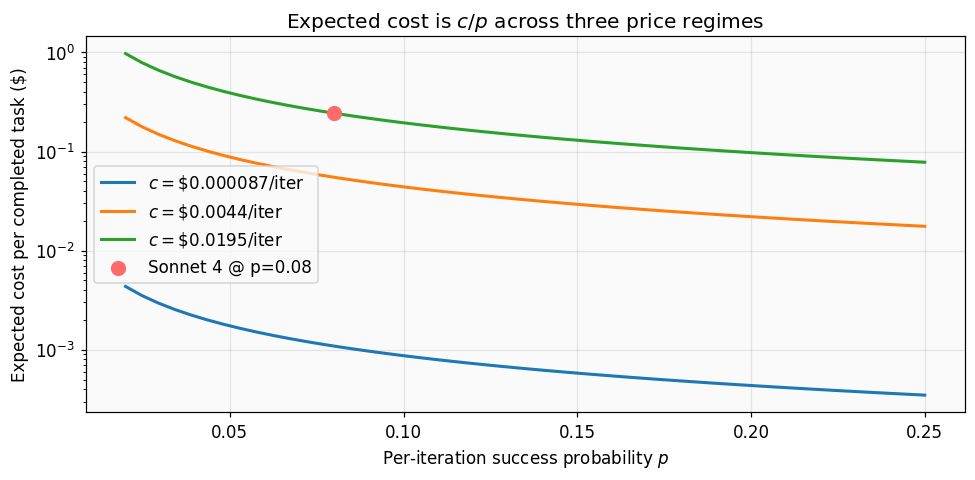

In [9]:
random.seed(42)
N_RUNS_COST = 2000
P_COST = 0.08
LLAMA_INPUT_PRICE = 0.027
LLAMA_OUTPUT_PRICE = 0.20
LLAMA_INPUT_TOKENS = 1_000
LLAMA_OUTPUT_TOKENS = 300
GPT41_INPUT_PRICE = 2.0
GPT41_OUTPUT_PRICE = 8.0
GPT41_INPUT_TOKENS = 1_000
GPT41_OUTPUT_TOKENS = 300
SONNET_INPUT_PRICE = 3.0
SONNET_OUTPUT_PRICE = 15.0
SONNET_INPUT_TOKENS = 4_000
SONNET_OUTPUT_TOKENS = 500

llama_cost = LLAMA_INPUT_TOKENS * LLAMA_INPUT_PRICE / 1_000_000 + LLAMA_OUTPUT_TOKENS * LLAMA_OUTPUT_PRICE / 1_000_000
gpt41_cost = GPT41_INPUT_TOKENS * GPT41_INPUT_PRICE / 1_000_000 + GPT41_OUTPUT_TOKENS * GPT41_OUTPUT_PRICE / 1_000_000
C_PER_ITER = SONNET_INPUT_TOKENS * SONNET_INPUT_PRICE / 1_000_000 + SONNET_OUTPUT_TOKENS * SONNET_OUTPUT_PRICE / 1_000_000

costs = np.array([ralph_loop_sim(P_COST, 1000)[0] * C_PER_ITER for _ in range(N_RUNS_COST)])

print(f"Llama 3.2 1B example    = ${llama_cost:.6f}  (1K in + 300 out)")
print(f"GPT-4.1 example         = ${gpt41_cost:.4f}  (1K in + 300 out)")
print(f"Claude Sonnet 4 example = ${C_PER_ITER:.4f}  (4K in + 500 out)")
print(f"Sonnet 4 / Llama ratio  = {C_PER_ITER / llama_cost:.0f}x")
print(f"Sonnet @ p={P_COST}:  E[cost] = c/p = ${C_PER_ITER / P_COST:.4f},  95th percentile = ${np.percentile(costs, 95):.2f}")

probs = np.linspace(0.02, 0.25, 50)
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in [llama_cost, gpt41_cost, C_PER_ITER]:
    label = f"$c = \\${c:.6f}$/iter" if c < 0.001 else f"$c = \\${c:.4f}$/iter"
    ax.plot(probs, c / probs, linewidth=2, label=label)
ax.scatter([P_COST], [C_PER_ITER / P_COST], color="#FF6B6B", s=80, zorder=5, label=f"Sonnet 4 @ p=0.08")
ax.set_xlabel("Per-iteration success probability $p$")
ax.set_ylabel("Expected cost per completed task ($)")
ax.set_title("Expected cost is $c/p$ across three price regimes")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

Here we see Llama at $\$0.000087$, GPT-4.1 at $\$0.0044$, Sonnet at $\$0.0195$, spanning four orders of magnitude. Sonnet is roughly $224\times$ more expensive per call than Llama.

The red dot is $c/p \approx \$0.24$ at $p = 0.08$. Slide right and you're asking "what if my prompt were stricter". Jump to the Llama curve at the same $p$ and you're asking "what if I were on the cheaper model".

The mean cost and the p95 cost are two different questions. The mean answers "what will I pay on average across many tasks". The p95 answers "how bad can ordinary bad luck get on a single task". At $p = 0.08$ the mean is $\$0.24$ and the p95 is $\$0.70$, about $2.8\times$ worse. That ratio is the geometric tail, and it widens as $p$ shrinks because $\mathrm{Var}(X) = (1-p)/p^2$. Budget against the mean for accounting, against the percentile for risk.

Now the break-even rule. Two models cost the same per completed task when

$$\frac{c_1}{p_1} = \frac{c_2}{p_2}, \qquad \text{or equivalently} \qquad \frac{c_2}{c_1} = \frac{p_2}{p_1}.$$

For Sonnet over Llama the price ratio is $\approx 224$, so Sonnet wins on total cost only if its per-iteration success rate is at least $224\times$ Llama's on the same task. A cheap model is not automatically cheaper per completed task. It has to succeed often enough that retries don't erase the per-call advantage. That's the question to ask before reaching for a frontier model: do you really need $224\times$ the $p$, or do you need a stricter prompt on the cheap model?

Let's test it in real life. We already have two real $\hat{p}$ values from Claim 2: $\hat{p}_\text{base}$ from the prompt with no edge-case rules, and $\hat{p}_\text{strict}$ from the prompt that names them. Plug those into $c/p$ for each of the three price regimes and you get a $3 \times 2$ table of actual dollar costs you'd pay running this same task end to end.

A small care is needed at the base prompt, where $\hat{p}=0/15$ blows up. Zero successes in 15 trials is not evidence of $p=0$, it's just a tight bound. The Laplace rule of succession gives a defensible point estimate $\hat{p}_\text{base} = (k+1)/(n+2) = 1/17 \approx 0.059$, which is what we use below. It's optimistic enough not to predict an infinite bill, pessimistic enough to keep the contrast honest.


model               prompt     p_hat      mean $       p95 $   E[iter]
Llama 3.2 1B        base       0.059      0.0015      0.0043     17.00
Llama 3.2 1B        strict     0.867      0.0001      0.0002      1.15
GPT-4.1             base       0.059      0.0747      0.2200     17.00
GPT-4.1             strict     0.867      0.0051      0.0088      1.15
Claude Sonnet 4     base       0.059      0.3372      0.9945     17.00
Claude Sonnet 4     strict     0.867      0.0224      0.0390      1.15

strict prompt on Llama  vs  base prompt on Sonnet:  $0.0001  vs  $0.3372
prompt edit on cheap model is 3367x cheaper than the model upgrade


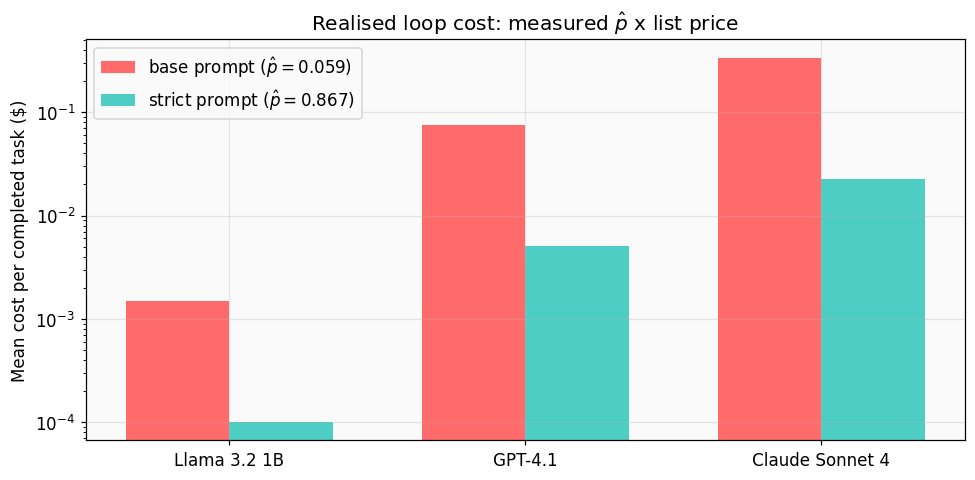

In [10]:
random.seed(42)
N_RUNS_EXP = 5000

p_base_hat = 1 / 17
p_strict_hat = 13 / 15

regimes = [
    ("Llama 3.2 1B", llama_cost),
    ("GPT-4.1", gpt41_cost),
    ("Claude Sonnet 4", C_PER_ITER),
]
prompts = [("base", p_base_hat), ("strict", p_strict_hat)]

print(f"{'model':<18}  {'prompt':<8}  {'p_hat':>6}  {'mean $':>10}  {'p95 $':>10}  {'E[iter]':>8}")
results = {}
for name, c in regimes:
    for prompt_name, p in prompts:
        sims = np.array([ralph_loop_sim(p, 500)[0] * c for _ in range(N_RUNS_EXP)])
        mean_cost, p95_cost = sims.mean(), np.percentile(sims, 95)
        results[(name, prompt_name)] = (mean_cost, p95_cost)
        print(f"{name:<18}  {prompt_name:<8}  {p:>6.3f}  {mean_cost:>10.4f}  {p95_cost:>10.4f}  {1 / p:>8.2f}")

llama_strict = results[("Llama 3.2 1B", "strict")][0]
sonnet_base = results[("Claude Sonnet 4", "base")][0]
print(f"\nstrict prompt on Llama  vs  base prompt on Sonnet:  ${llama_strict:.4f}  vs  ${sonnet_base:.4f}")
print(f"prompt edit on cheap model is {sonnet_base / llama_strict:.0f}x cheaper than the model upgrade")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(regimes))
width = 0.35
base_means = [results[(name, "base")][0] for name, _ in regimes]
strict_means = [results[(name, "strict")][0] for name, _ in regimes]
ax.bar(x - width / 2, base_means, width, color="#FF6B6B", label=f"base prompt ($\\hat p={p_base_hat:.3f}$)")
ax.bar(x + width / 2, strict_means, width, color="#4ECDC4", label=f"strict prompt ($\\hat p={p_strict_hat:.3f}$)")
ax.set_xticks(x)
ax.set_xticklabels([name for name, _ in regimes])
ax.set_ylabel("Mean cost per completed task ($)")
ax.set_yscale("log")
ax.set_title("Realised loop cost: measured $\\hat p$ x list price")
ax.legend()
plt.tight_layout()
plt.show()


This is a visual representation of what we said - cheap and expensive doesn't depend on the tokens' cost - but the probability of getting a successful result. For our simple prompts above, Llama out performed the better frontier models.

## The Loop as a Regret Bound

Huntley's claims look like separate facts, but are actually a regret loop. Defining regret as iterations spent beyond the oracle (one shot, instant solve):


$$E[\text{regret}] = E[X] - 1 = \frac{1-p}{p}.$$

Each retry past the first is a wasted attempt, and on average there are $(1-p)/p$ of them. Multiply by $c$ and you have the cost result. Differentiate,

$$\frac{d}{dp}\frac{1-p}{p} = \frac{d}{dp}\!\left(\frac{1}{p} - 1\right) = -\frac{1}{p^2},$$

and the marginal value of a $\Delta p$ improvement scales as $1/p^2$. The first guardrail rule on a weak prompt is worth far more than the tenth on a decent one.

The geometric assumption is also doing more work than it looks. It's a prior over a memoryless loop. Real Ralph runs are implicitly Bayesian: the model itself is stateless, but the filesystem is the posterior, and the next attempt samples from $P(\text{success} \mid \text{partial edits, failing tests, prior outputs})$ rather than from a constant $p$. When that posterior drifts upward the completion-time distribution tightens; when it drifts downward the tail fattens.

In Huntley's own write-up, $p$ is held roughly stationary by deliberate operator hygiene: one task per loop, a fixed specs folder, a `fix_plan.md` and `AGENT.md` allocated into context every iteration, and subagents fanned out for expensive reads so the main context window stays small. Each rule maps to the heap analogy. One task per loop bounds total allocation per iteration. The fixed specs folder is the deterministic re-allocation at the top of the heap. Subagents are allocation isolation: their reads die with them. The bash `while` loop is the only garbage collector you get, and it only fires between iterations, so you can't recover from an over-allocated pass; you can only avoid it on the next one. All of that is what holds the posterior steady and keeps the geometric story usable as a baseline.

## When the Geometric Math doesn't Math

A fair objection at this point: the chi-squared in Claim 1 sat at $p = 0.665$, but that was a synthetic sim where every iteration drew from the same coin. Of course it fit, we built it that way. The real Ralph loop is different. The filesystem carries state across iterations, so the per-call success probability is not a fixed $p$, it's a sequence $p_1, p_2, p_3, \ldots$ that drifts as the prompt grows and the workspace changes.

That drift goes in one of two directions, and which one you're in is something you can actually measure.

**Progress accumulates: $p_t$ rises.** Each failed iteration leaves better failing-test output, partial edits, or a clearer scratchpad in the workspace. The next attempt starts from a stronger position than the last. Completion times come in tighter than geometric: fewer ones, more clustering near the median, a shorter right tail. If you plot a histogram against $\text{Geometric}(\bar p)$ with $\bar p$ matched to the empirical mean, the empirical distribution underweights the tail.

**Iterations interfere: $p_t$ falls.** Context fills with stale tool output, the model gets fixated on a wrong approach, partial edits leave the workspace in a worse state than it started, or rate limits truncate completions. The next attempt has a lower per-call probability than the last. Completion times fatten in the tail, and a small fraction of runs blow well past $3/p$ or hit the iteration cap. Same plot, opposite direction: the empirical distribution overweights the tail.

In both cases, if you run the loop many times on the same task, plot completion times, overlay $\text{Geometric}(\bar p)$, and look at the tail. A tighter empirical tail means your prompt hygiene is working. A fatter one means something is degrading $p_t$ over the iteration index, and the geometric mean $1/\bar p$ is now an *optimistic* bound on cost, not an accurate one. The $c/p$ arithmetic still gives you the right shape, but the operating point shifts under your feet.

The other limit on Ralph is scope, not maths. The loop only works when success is machine-checkable and calls are cheap. Subjective success (does this prose read well, is this design right) gives the verifier no signal, so the loop has no idea when to stop. Huntley is blunt: Ralph is a Greenfield bootstrap, gets you maybe 90% of the way, and is the wrong tool for a brownfield codebase where the verifier signal is muddied by prior decisions you didn't make. That's a different failure mode from the maths breaking. The maths can hold perfectly and the loop still produces nothing useful if the verifier is the wrong instrument.


## Conclusion

The Ralph loop looks like a joke, but we see that it does work. 

Wrap any stochastic worker in retry-until-pass and you've described a Bernoulli process. From that one one change, everything becomes defined: $E[X] = 1/p$ for how many attempts the loop will take, $E[\text{cost}] = c/p$ for what it costs, and $c_1/p_1 = c_2/p_2$ for whether a more expensive model is actually the cheaper one.

From our tests, a one-line prompt rule lifted the Llama 3.2 1B per-call success rate from effectively zero to $\hat{p} \approx 0.87$, which is a roughly $15\times$ cut in expected iterations. A model upgrade from Llama to Sonnet is a $224\times$ jump in per-call price. Multiply them together and the strict prompt on the cheap model came in around $3{,}300\times$ cheaper per completed task than the weak prompt on the frontier one. The two levers are not additive, they multiply, and the prompt is the one most people leave on the table.

That's the working rule the article leaves you with. 

Before you reach for a bigger model, measure $\hat{p}$ on the small one and ask whether one or two rules in the prompt can close the gap. Most of the time they can, and the savings compound with the price ratio you didn't have to pay.


## References

1. Huntley, G. *Ralph Wiggum as a "software engineer"*. https://ghuntley.com/ralph/
2. Huntley, G. *I dream about AI subagents; they whisper to me while I'm asleep*. https://ghuntley.com/subagents/
3. Huntley, G. *From design doc to code: the Groundhog AI coding assistant*. https://ghuntley.com/specs/
4. Anthropic. *Claude Code: Hooks reference*. https://docs.claude.com/en/docs/claude-code/hooks
5. Anthropic. *Claude Code documentation*. https://docs.claude.com/en/docs/claude-code
6. OpenRouter. *Model pricing*. https://openrouter.ai/models
7. Statlect. *Geometric distribution*. https://www.statlect.com/probability-distributions/geometric-distribution
8. Darmanin, A. *Less is more for LLMs: a critique of prompt-based compression*. https://medium.com/call-for-atlas/less-is-more-for-llms-a-critique-of-prompt-based-compression-910978d8bad4
9. Darmanin, A. *The road to agency: how prompts work*. https://medium.com/call-for-atlas/the-road-to-agency-how-prompts-work-c7cadc684b0f


GitHub repository: [here](https://github.com/adamd1985/quant_research/blob/main/ralph_wiggum_loop.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/wiggum-loop)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.
